# Image Classification with Convolutional Neural Networks

In [ ]:

import kagglehub
salader_dogsvscats_path = kagglehub.dataset_download('salader/dogsvscats')

print('Data source import complete.')


Using Colab cache for faster access to the 'dogsvscats' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Streaming output truncated to the last 5000 lines.
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.12067.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.6754.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.12113.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.2602.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.9283.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.5087.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.10515.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.10254.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.6611.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.8950.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.12290.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.4134.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.8313.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.6452.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cats/cat.244.jpg
/kaggle/input/dogsvscats/catsvsdogs/train/cat

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

## Model 1: Initial CNN Architecture

This section defines, compiles, and trains the first Convolutional Neural Network model. This initial model serves as a baseline to identify common issues like overfitting and to establish a performance benchmark.

In [ ]:
import os

# Define the path to your training data.
# 'salader_dogsvscats_path' was defined in an earlier cell and points to '/kaggle/input/dogsvscats'.
train_dir = os.path.join(salader_dogsvscats_path, 'catsvsdogs', 'train')
# Define the path to your test/validation data
test_dir = os.path.join(salader_dogsvscats_path, 'catsvsdogs', 'test')

# Create a training dataset using Image_dataset_from_directory
# This function infers the labels from the directory structure.
# For example, images in 'train/cats' will be labeled 'cats' and 'train/dogs' will be 'dogs'.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int', # 'int' for integer encoding (e.g., 0, 1 for cat, dog)
    image_size=(256, 256), # Resize images to 256x256 pixels

    batch_size=32,

)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int', # 'int' for integer encoding (e.g., 0, 1 for cat, dog)
    image_size=(256, 256), # Resize images to 256x256 pixels

    batch_size=32,

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
#Normalize pixes values will be formed in between o to 1 so our model performs well
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 142ms/step - accuracy: 0.6133 - loss: 0.6652 - val_accuracy: 0.7006 - val_loss: 0.5791
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7303 - loss: 0.5320 - val_accuracy: 0.7458 - val_loss: 0.5521
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8164 - loss: 0.3971 - val_accuracy: 0.7304 - val_loss: 0.7393
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9080 - loss: 0.2214 - val_accuracy: 0.7464 - val_loss: 0.9534
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9560 - loss: 0.1165 - val_accuracy: 0.7548 - val_loss: 1.0632
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.9720 - loss: 0.0821 - val_accuracy: 0.7516 - val_loss: 1.1839
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9834 - loss: 0.0502 - val_accuracy: 0.7480 - val_loss: 1.3765
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9873 - loss: 0.0425 

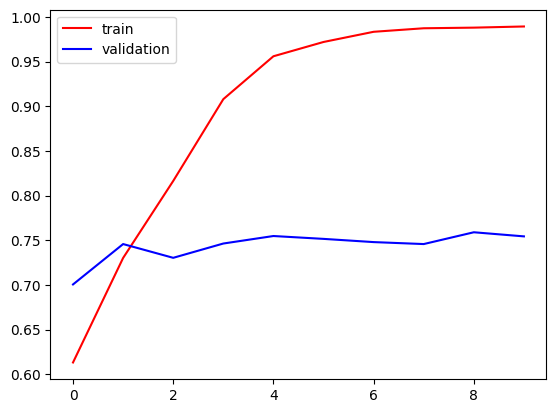

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

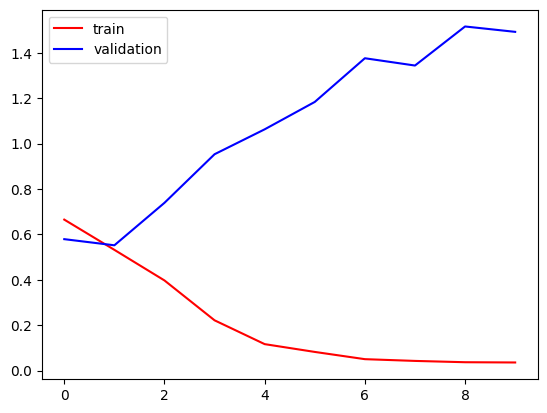

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

From the plots, Model 1 shows signs of **overfitting**: training accuracy increases rapidly while validation accuracy plateaus, and training loss decreases while validation loss increases.

Overfitting occurs when a model learns the training data too well, including noise, leading to poor generalization on unseen data. This is evident when training accuracy is significantly higher than validation accuracy.

Common strategies to mitigate overfitting:
*   **Add more data/Data Augmentation**: Increase training data size and diversity.
*   **Regularization (L1/L2, Dropout)**: Penalize large weights or randomly drop neurons to prevent co-adaptation.
*   **Batch Normalization**: Stabilize learning and act as a regularizer.
*   **Reduce complexity**: Simplify the model architecture.

## Batch Normalization

Batch Normalization standardizes layer inputs, stabilizing training, reducing epochs, and making the network less sensitive to initial weights. It also functions as a regularizer.

In [ ]:
from keras.layers import BatchNormalization,Dropout

In [ ]:

model2 = Sequential()

model2.add(Conv2D(32,(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model2.add(Conv2D(64,(3,3),padding='valid',activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model2.add(Conv2D(128,(3,3),padding='valid',activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model2.add(Flatten())

model2.add(Dense(128,activation='relu'))
model2.add(Dropout(0.1))
model2.add(Dense(64,activation='relu'))
model2.add(Dropout(0.1))
model2.add(Dense(1,activation='sigmoid'))

## Model 2: Improved CNN Architecture with Regularization

To address the overfitting observed in Model 1, this section introduces an improved CNN architecture, `model2`, which incorporates `BatchNormalization` and `Dropout` layers. These techniques are commonly used to regularize neural networks and improve their generalization capabilities.

In [ ]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history2 = model2.fit(train_ds,epochs=10,validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.6047 - loss: 1.1239 - val_accuracy: 0.5686 - val_loss: 1.5103
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.6895 - loss: 0.5960 - val_accuracy: 0.6750 - val_loss: 0.6274
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.7466 - loss: 0.5179 - val_accuracy: 0.6930 - val_loss: 0.5967
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7936 - loss: 0.4451 - val_accuracy: 0.7630 - val_loss: 0.5114
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.8260 - loss: 0.3845 - val_accuracy: 0.7854 - val_loss: 0.4529
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8651 - loss: 0.3144 - val_accuracy: 0.8282 - val_loss: 0.4586
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.8978 - loss: 0.2434 - val_accuracy: 0.8010 - val_loss: 0.4744
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9325 - loss: 0.1701 - 

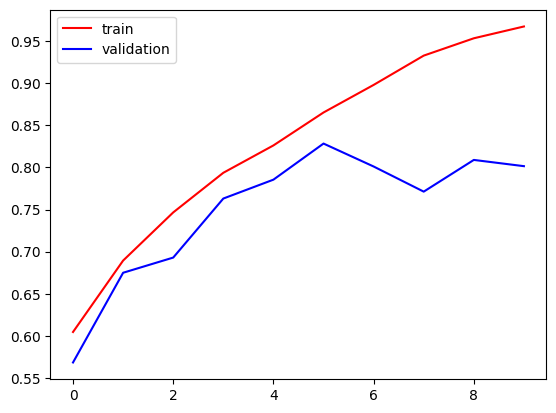

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history['accuracy'],color='red',label='train')
plt.plot(history2.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

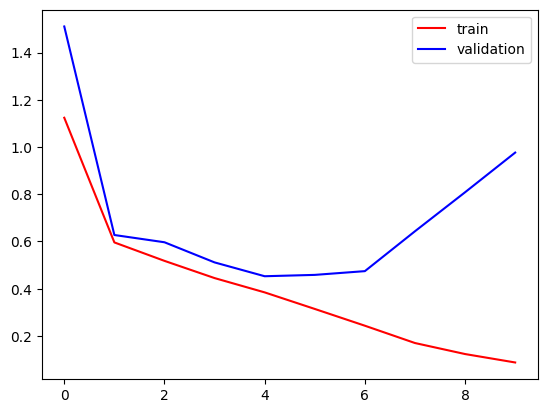

In [ ]:
plt.plot(history2.history['loss'],color='red',label='train')
plt.plot(history2.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

### Comparison of Model 1 and Model 2 Performance

By comparing the training and validation accuracy/loss plots for both `model` and `model2`, we can evaluate the effectiveness of the added regularization techniques. Ideally, `model2` should show a smaller gap between training and validation performance, indicating better generalization.

From the plots of `model2`, we can see that while there's still some gap, the validation accuracy is higher and the validation loss is lower compared to `model1` at the end of training. This suggests that `BatchNormalization` and `Dropout` have helped in mitigating overfitting.

In [ ]:
import cv2

## Testing the Model with New Images

This section demonstrates how to use the trained `model2` to predict whether a new image contains a cat or a dog. We will load example images, preprocess them to match the model's input requirements, and then use the model to make predictions.

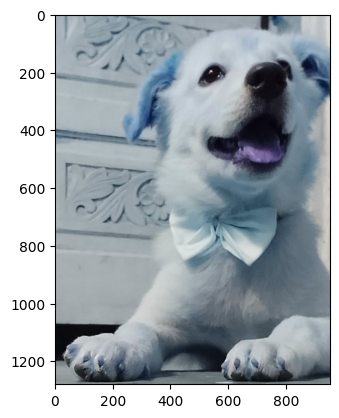

In [ ]:
test_img = cv2.imread('/content/dog.jpeg')
plt.imshow(test_img)

In [ ]:
test_img.shape

(1280, 952, 3)

In [ ]:
test_img = cv2.resize(test_img,(256,256))
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model2.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

The prediction output of `1.0` indicates that the model classifies this image as a **dog**.

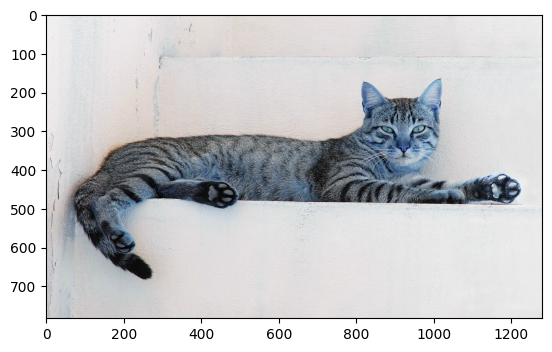

In [ ]:
test_img = cv2.imread('/content/Cat.jpg')
plt.imshow(test_img)

In [ ]:
test_img.shape

(783, 1280, 3)

In [ ]:
test_img = cv2.resize(test_img,(256,256))
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model2.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[0.]], dtype=float32)

The prediction output of `0.0` indicates that the model classifies this image as a **cat**.